In [52]:
# Supermarket wants to send promotional offers to its cutomers based on their purchasing behavior.
# We will perform clustering analysis to segment the customers based on their annual spending on different product categories

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
cust_Data = pd.read_csv(r'datasets\Wholesale_customers_data.csv')

In [53]:
# Spending of customer under various product categories
cust_Data.head()

,Cust_id,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicatessen
0,1,2,3,12669,9656,7561,214,2674,1338
1,2,2,3,7057,9810,9568,1762,3293,1776
2,3,2,3,6353,8808,7684,2405,3516,7844
3,4,1,3,13265,1196,4221,6404,507,1788
4,5,2,3,22615,5410,7198,3915,1777,5185


In [54]:
cust_Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Cust_id           440 non-null    int64
 1   Channel           440 non-null    int64
 2   Region            440 non-null    int64
 3   Fresh             440 non-null    int64
 4   Milk              440 non-null    int64
 5   Grocery           440 non-null    int64
 6   Frozen            440 non-null    int64
 7   Detergents_Paper  440 non-null    int64
 8   Delicatessen      440 non-null    int64
dtypes: int64(9)
memory usage: 31.1 KB


In [55]:
cust_Data.columns

Index(['Cust_id', 'Channel', 'Region', 'Fresh', 'Milk', 'Grocery', 'Frozen',
       'Detergents_Paper', 'Delicatessen'],
      dtype='object')

In [56]:
cust_Data.describe()
# Chanel represents retail:2 and wholesale customers:1
# Region is 1:Lisbon 2:Oporto 3:Other region

,Cust_id,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicatessen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,220.500000,1.322727,2.543182,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,127.161315,0.468052,0.774272,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,1.000000,1.000000,1.000000,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,110.750000,1.000000,2.000000,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,220.500000,1.000000,3.000000,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,330.250000,2.000000,3.000000,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,440.000000,2.000000,3.000000,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000


In [57]:
cust_Data.shape

(440, 9)

In [58]:
# Sample 5 random rows
pd.set_option('display.max_columns', None)

cust_Data.sample (n=5, random_state=42)

,Cust_id,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicatessen
265,266,1,1,5909,23527,13699,10155,830,3636
78,79,1,3,10766,1175,2067,2096,301,167
347,348,2,3,27380,7184,12311,2809,4621,1022
255,256,1,1,31614,489,1495,3242,111,615
327,328,1,2,542,899,1664,414,88,522


In [59]:
# Frequency Counts
cust_Data['Channel'].value_counts()


Channel
1    298
2    142
Name: count, dtype: int64

In [60]:
cust_Data['Region'].value_counts()

Region
3    316
1     77
2     47
Name: count, dtype: int64

In [61]:
round(cust_Data.describe(),2)

,Cust_id,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicatessen
count,440.00,440.00,440.00,440.00,440.00,440.00,440.00,440.00,440.00
mean,220.50,1.32,2.54,12000.30,5796.27,7951.28,3071.93,2881.49,1524.87
std,127.16,0.47,0.77,12647.33,7380.38,9503.16,4854.67,4767.85,2820.11
min,1.00,1.00,1.00,3.00,55.00,3.00,25.00,3.00,3.00
25%,110.75,1.00,2.00,3127.75,1533.00,2153.00,742.25,256.75,408.25
50%,220.50,1.00,3.00,8504.00,3627.00,4755.50,1526.00,816.50,965.50
75%,330.25,2.00,3.00,16933.75,7190.25,10655.75,3554.25,3922.00,1820.25
max,440.00,2.00,3.00,112151.00,73498.00,92780.00,60869.00,40827.00,47943.00


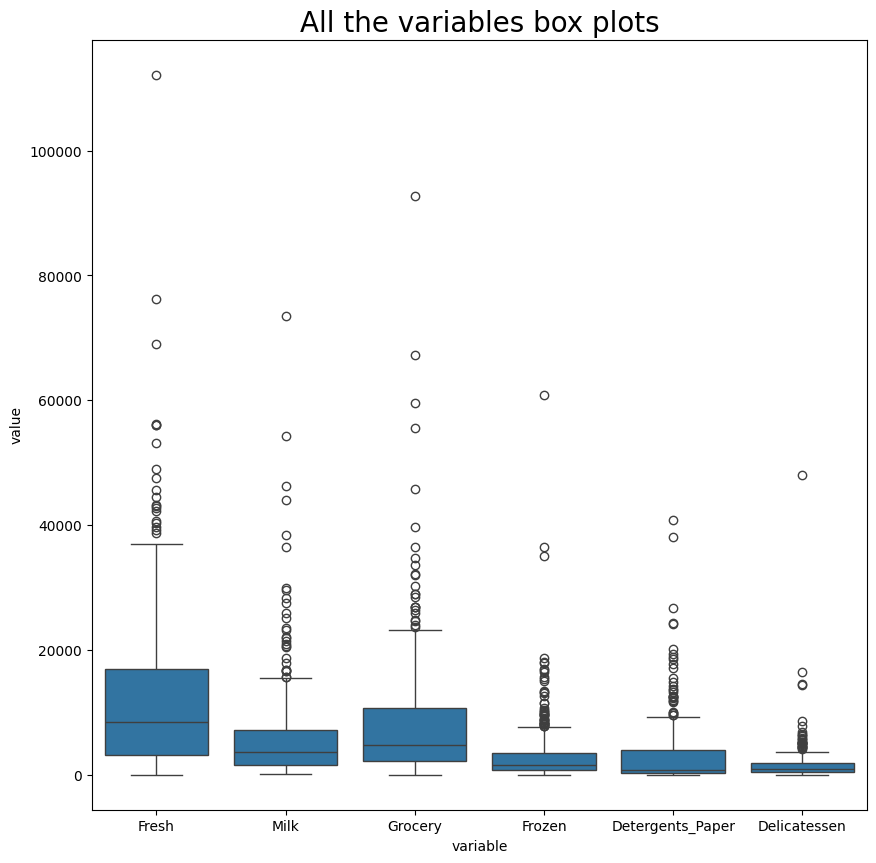

In [62]:
#Focusing only on the numeric columns for clustering

# Box Plot to check for outliers
plt.figure(figsize=(10,10))
plt.title("All the variables box plots", size=20)
sns.boxplot(x="variable", y="value", data=pd.melt(cust_Data[['Fresh', 'Milk', 'Grocery','Frozen', 'Detergents_Paper', 'Delicatessen']]))
plt.show()

In [63]:
# Business Problem and Objective

# Divide customers into different segments and send segment specific promotional offers to increase sales.

# And promote cross-selling of products and up-selling of products.

# Fresh items are most sold ones in the supermarket.
# Find customer segments where fresh items are less sold than other items like grocery or milk

# measuring distance
cust_Data_sample = cust_Data.sample (n=5, random_state=11)
cust_Data_sample[['Cust_id','Fresh', 'Grocery']]

,Cust_id,Fresh,Grocery
182,183,694,10518
399,400,9612,935
317,318,1182,6114
146,147,7769,2177
200,201,3067,23127


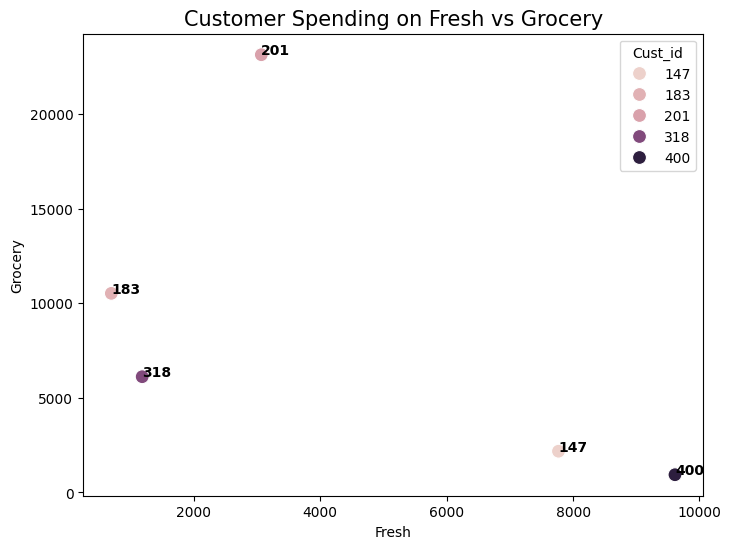

In [64]:
plt.figure(figsize=(8,6))
plt.title("Customer Spending on Fresh vs Grocery", size=15)
plot = sns.scatterplot(x='Fresh', y='Grocery', data=cust_Data_sample, hue='Cust_id', s=100)
for line in range(0,cust_Data_sample.shape[0]):
    plot.text(cust_Data_sample.Fresh.iloc[line]+0.2, cust_Data_sample.Grocery.iloc[line], 
              cust_Data_sample.Cust_id.iloc[line], horizontalalignment='left', 
              size='medium', color='black', weight='semibold')

In [65]:
# Customers 183 and 318 are close to each other
# Customers 147 and 400 are also close to each other

# We use Euclidean distance formula to calculate the distance between two customers
# Create distance matrix for the sample data

def distance_cal(data_frame):
    distance_matrix = np.zeros((data_frame.shape[0], data_frame.shape[0]))
    for i in range(0,data_frame.shape[0]):
        for j in range(0,data_frame.shape[0]):
            distance_matrix[i][j] = round(np.sqrt((data_frame.Fresh.iloc[i]-data_frame.Fresh.iloc[j])**2 + 
                                            (data_frame.Grocery.iloc[i]-data_frame.Grocery.iloc[j])**2))
    return distance_matrix

distance_matrix = distance_cal(cust_Data_sample[['Fresh', 'Grocery']])
print(distance_matrix)

[[    0. 13091.  4431. 10937. 12830.]
 [13091.     0.  9894.  2222. 23137.]
 [ 4431.  9894.     0.  7674. 17117.]
 [10937.  2222.  7674.     0. 21471.]
 [12830. 23137. 17117. 21471.     0.]]


In [66]:
# C Ids 183,318, 201, 147, 400

In [ ]:
# k Means Clustering Algorithm based on similarity (distance)
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=5, random_state=333)

X =cust_Data.drop(['Cust_id','Channel','Region'], axis=1)
# Model building
kmeans = kmeans.fit(X)

# Getting the cluster labels and attaching them to org data

cust_Data_clusters = cust_Data
cust_Data_clusters["Cluster_id"] = kmeans.predict(X)
cust_Data_clusters.head()

,Cust_id,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicatessen,Cluster_id
0,1,2,3,12669,9656,7561,214,2674,1338,1
1,2,2,3,7057,9810,9568,1762,3293,1776,1
2,3,2,3,6353,8808,7684,2405,3516,7844,1
3,4,1,3,13265,1196,4221,6404,507,1788,4
4,5,2,3,22615,5410,7198,3915,1777,5185,4


In [72]:
cluster_counts = cust_Data_clusters['Cluster_id'].value_counts().sort_index()
clsuter_means = cust_Data_clusters.groupby('Cluster_id').mean()

print("Cluster Counts:\n", cluster_counts)
print("\nCluster Means:\n", round(clsuter_means,2))

Cluster Counts:
 Cluster_id
0     23
1    235
2     64
3      5
4    113
Name: count, dtype: int64

Cluster Means:
             Cust_id  Channel  Region     Fresh      Milk   Grocery   Frozen  \
Cluster_id                                                                    
0            212.48     1.09    2.70  49296.09   4983.78   5590.30  8285.78   
1            229.16     1.23    2.55   5608.33   3766.51   4765.07  2354.20   
2            209.80     1.94    2.41   5378.67  13535.98  22106.39  1679.55   
3             93.40     1.80    3.00  31259.40  51254.60  52046.60  9916.60   
4            215.81     1.19    2.55  20600.28   3787.83   5089.84  3989.07   

            Detergents_Paper  Delicatessen  
Cluster_id                                  
0                     962.26       2543.70  
1                    1608.82       1009.60  
2                    9811.55       2026.50  
3                   22401.60      12054.40  
4                    1130.14       1639.07  


Text(0.5, 1.0, 'Spending Distribution across Product Categories by Cluster')

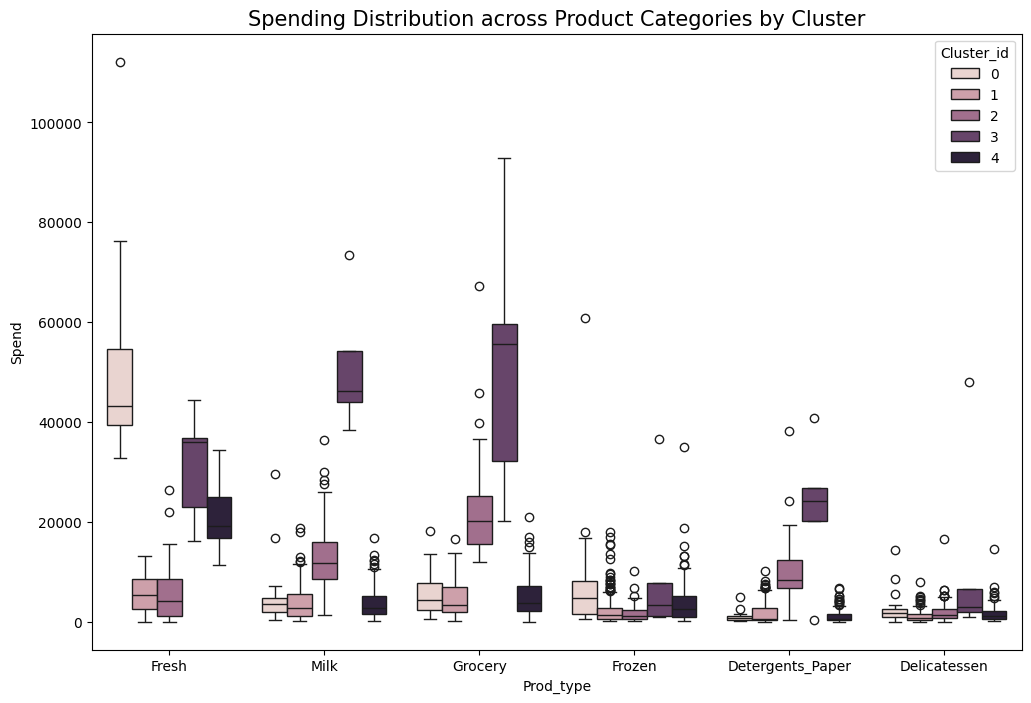

In [73]:
# Cluster 3 despite only having 5 customers, has very high average spending across 
# Milk, Grocery, and Fresh category
# Box plotting this

df_melt = pd.melt(cust_Data_clusters.drop(['Cust_id','Channel','Region'], axis=1), "Cluster_id", var_name="Prod_type", value_name= "Spend")
plt.figure(figsize=(12,8))
sns.boxplot(x="Prod_type", y="Spend", hue="Cluster_id", data=df_melt)
plt.title("Spending Distribution across Product Categories by Cluster", size=15)

Text(0.5, 1.0, 'Cluster 3 Spending Distribution across Product Categories')

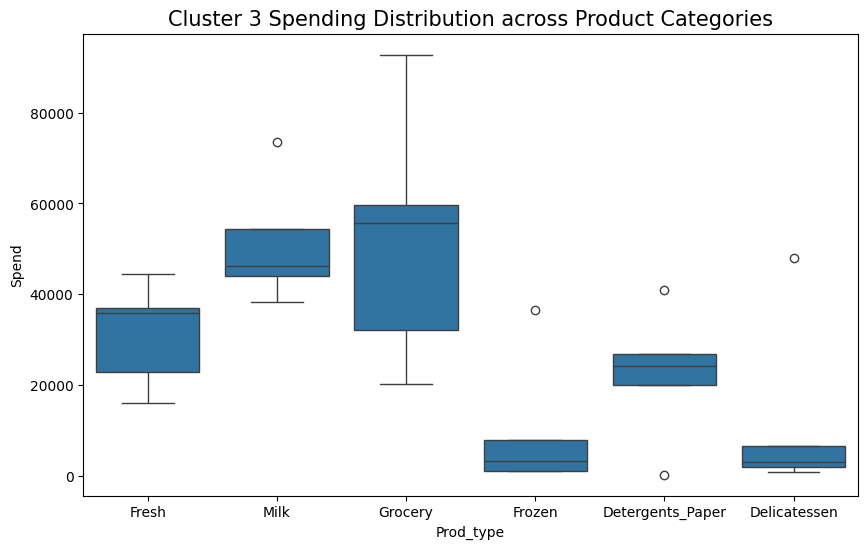

In [74]:
# individual box plots

Cluster = df_melt[df_melt['Cluster_id']==3]
plt.figure(figsize=(10,6))
sns.boxplot(x="Prod_type", y="Spend", data=Cluster)
plt.title("Cluster 3 Spending Distribution across Product Categories", size=15)

In [ ]:
# Fresh items are most sold ones in the supermarket.
# Find customer segments where fresh items are less sold than other items like grocery or milk


Cluster = df_melt[df_melt['Cluster_id']==3]
plt.figure(figsize=(10,6))
sns.boxplot(x="Prod_type", y="Spend", data=Cluster)
plt.title("Cluster 3 Spending Distribution across Product Categories", size=15)